In [2]:
# ==============================
# PHASE 1: TRADITIONAL ML PIPELINE
# Airbus Ship Detection
# ==============================

# --- IMPORTS ---
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray
from skimage import io
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ==============================
# STEP 1: LOAD DATASET METADATA (LOCAL)
# ==============================
import os
import pandas as pd

# 🧭 Correct path to the data folder one level above /models
BASE_PATH = os.path.join(os.path.dirname(os.getcwd()), "data")
TRAIN_CSV = os.path.join(BASE_PATH, "annotations_selected.csv")
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "selected_15k")

print("Using BASE_PATH:", BASE_PATH)
print("TRAIN_CSV:", TRAIN_CSV)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
assert os.path.exists(TRAIN_CSV), f"CSV not found: {TRAIN_CSV}"
assert os.path.exists(TRAIN_IMG_DIR), f"Image folder not found: {TRAIN_IMG_DIR}"

# Load and prepare dataframe (one row per image)
df_raw = pd.read_csv(TRAIN_CSV)
df = df_raw.groupby('ImageId')['EncodedPixels'].apply(lambda s: s.notnull().any()).reset_index()
df.columns = ['ImageId', 'has_ship']
df['has_ship'] = df['has_ship'].astype(int)

print(f"Total images in CSV: {len(df)}, Ships: {df['has_ship'].sum()}, No Ships: {len(df)-df['has_ship'].sum()}")

# ==============================
# STEP 2: TRAIN / TEST SPLIT (fixed 12k train / 3k test)
# ==============================
from sklearn.model_selection import train_test_split

# total = 15,000 → test_size = 3,000 → test_size fraction = 3_000 / 15_000 = 0.2
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=9, stratify=df['has_ship']
)

y_train = train_df['has_ship'].values
y_test = test_df['has_ship'].values

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# ==============================
# STEP 3: SAFE IMAGE LOADING
# ==============================
IMG_SIZE = 256   # ✅ Resize 256×256

def safe_load_image(img_path, img_size=IMG_SIZE):
    try:
        img = io.imread(img_path)
        if img is None:
            return None
        img = cv2.resize(img, (img_size, img_size))
        if img.ndim == 2:  # grayscale -> RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] > 3:
            img = img[:, :, :3]
        return img
    except Exception:
        return None

def load_images_with_retry(df, img_dir, img_size=IMG_SIZE):
    X_images = []
    y_labels = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(img_dir, row['ImageId'])
        img = safe_load_image(img_path, img_size)
        if img is not None:
            X_images.append(img)
            y_labels.append(row['has_ship'])
    return np.array(X_images), np.array(y_labels)

print("Loading training images...")
X_train, y_train = load_images_with_retry(train_df, TRAIN_IMG_DIR)
print("Loading testing images...")
X_test, y_test = load_images_with_retry(test_df, TRAIN_IMG_DIR)

print(f"Successfully loaded: Train={len(X_train)}, Test={len(X_test)}")

Using BASE_PATH: c:\Users\shour\Desktop\AirBus\Airbus_Ship_Detection\data
TRAIN_CSV: c:\Users\shour\Desktop\AirBus\Airbus_Ship_Detection\data\annotations_selected.csv
TRAIN_IMG_DIR: c:\Users\shour\Desktop\AirBus\Airbus_Ship_Detection\data\selected_15k
Total images in CSV: 15000, Ships: 9000, No Ships: 6000
Train: 12000, Test: 3000
Loading training images...


100%|██████████| 12000/12000 [03:41<00:00, 54.22it/s]


Loading testing images...


100%|██████████| 3000/3000 [01:22<00:00, 36.39it/s]


Successfully loaded: Train=12000, Test=3000


In [3]:
# ==============================
# STEP 4: FEATURE EXTRACTION FUNCTIONS
# ==============================
def extract_hu_moments(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    moments = cv2.moments(gray)
    hu = cv2.HuMoments(moments).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-7)
    return hu

def extract_haralick_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        symmetric=True, normed=True)
    props = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'ASM', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop)
        props.append(vals.mean())
    return np.array(props)

def extract_color_histogram(img, bins=(8,8,8)):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, bins, [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# ==============================
# STEP 5: BUILD FEATURE SETS
# ==============================
print("Extracting features for training set...")
train_hu = np.array([extract_hu_moments(img) for img in tqdm(X_train)])
train_ha = np.array([extract_haralick_features(img) for img in tqdm(X_train)])
train_his = np.array([extract_color_histogram(img) for img in tqdm(X_train)])

print("Extracting features for testing set...")
test_hu = np.array([extract_hu_moments(img) for img in tqdm(X_test)])
test_ha = np.array([extract_haralick_features(img) for img in tqdm(X_test)])
test_his = np.array([extract_color_histogram(img) for img in tqdm(X_test)])


Extracting features for training set...


100%|██████████| 12000/12000 [00:01<00:00, 6949.68it/s]


Extracting features for testing set...


100%|██████████| 3000/3000 [00:00<00:00, 6974.56it/s]


In [4]:
# ==============================
# STEP 6: MODEL EVALUATION FUNCTION
# ==============================
def evaluate_models(X_train, X_test, y_train, y_test, label_suffix):
    print(f"\n➡ Evaluating models for feature set: {label_suffix} ...")
    
    # ✅ Use MinMaxScaler instead of StandardScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        "LDA": LinearDiscriminantAnalysis(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes": GaussianNB(),
        "Random Forest": RandomForestClassifier(
            n_estimators=140, max_depth=30, min_samples_leaf=1,
            max_features='sqrt', random_state=9
        ),
        "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=9)
    }

    results = {}
    for name, model in models.items():
        print(f"   Training {name} ...", end="")
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        results[f"{name} | {label_suffix}"] = acc
        print(f" Done! Accuracy: {acc*100:.2f}%")
    print(f"✅ Completed feature set: {label_suffix}")
    return results


In [5]:
# ==============================
# STEP 7: TRAINING ALL COMBINATIONS
# ==============================
results = {}
results.update(evaluate_models(train_his, test_his, y_train, y_test, "His"))
results.update(evaluate_models(train_ha, test_ha, y_train, y_test, "Ha"))
results.update(evaluate_models(train_hu, test_hu, y_train, y_test, "Hu"))
results.update(evaluate_models(np.hstack((train_hu, train_ha)),
                               np.hstack((test_hu, test_ha)), y_train, y_test, "Hu+Ha"))
results.update(evaluate_models(np.hstack((train_ha, train_his)),
                               np.hstack((test_ha, test_his)), y_train, y_test, "Ha+His"))
results.update(evaluate_models(np.hstack((train_hu, train_his)),
                               np.hstack((test_hu, test_his)), y_train, y_test, "Hu+His"))
results.update(evaluate_models(np.hstack((train_hu, train_ha, train_his)),
                               np.hstack((test_hu, test_ha, test_his)), y_train, y_test, "All"))


➡ Evaluating models for feature set: His ...
   Training LDA ... Done! Accuracy: 71.27%
   Training KNN ... Done! Accuracy: 75.80%
   Training Naive Bayes ... Done! Accuracy: 48.63%
   Training Random Forest ... Done! Accuracy: 91.77%
   Training SVM ... Done! Accuracy: 75.80%
✅ Completed feature set: His

➡ Evaluating models for feature set: Ha ...
   Training LDA ... Done! Accuracy: 65.57%
   Training KNN ... Done! Accuracy: 70.73%
   Training Naive Bayes ... Done! Accuracy: 60.60%
   Training Random Forest ... Done! Accuracy: 78.07%
   Training SVM ... Done! Accuracy: 67.87%
✅ Completed feature set: Ha

➡ Evaluating models for feature set: Hu ...
   Training LDA ... Done! Accuracy: 62.00%
   Training KNN ... Done! Accuracy: 59.00%
   Training Naive Bayes ... Done! Accuracy: 61.07%
   Training Random Forest ... Done! Accuracy: 65.20%
   Training SVM ... Done! Accuracy: 60.90%
✅ Completed feature set: Hu

➡ Evaluating models for feature set: Hu+Ha ...
   Training LDA ... Done! Accura


✅ Final Accuracies:
LDA | His: 71.27%
LDA | Ha: 65.57%
LDA | Hu: 62.00%
LDA | Hu+Ha: 67.47%
LDA | Ha+His: 76.60%
LDA | Hu+His: 72.33%
LDA | All: 77.23%
KNN | His: 75.80%
KNN | Ha: 70.73%
KNN | Hu: 59.00%
KNN | Hu+Ha: 71.70%
KNN | Ha+His: 81.47%
KNN | Hu+His: 71.10%
KNN | All: 75.97%
Naive Bayes | His: 48.63%
Naive Bayes | Ha: 60.60%
Naive Bayes | Hu: 61.07%
Naive Bayes | Hu+Ha: 61.03%
Naive Bayes | Ha+His: 48.67%
Naive Bayes | Hu+His: 48.93%
Naive Bayes | All: 48.97%
Random Forest | His: 91.77%
Random Forest | Ha: 78.07%
Random Forest | Hu: 65.20%
Random Forest | Hu+Ha: 82.07%
Random Forest | Ha+His: 92.67%
Random Forest | Hu+His: 92.23%
Random Forest | All: 92.13%
SVM | His: 75.80%
SVM | Ha: 67.87%
SVM | Hu: 60.90%
SVM | Hu+Ha: 67.80%
SVM | Ha+His: 80.80%
SVM | Hu+His: 71.23%
SVM | All: 78.17%


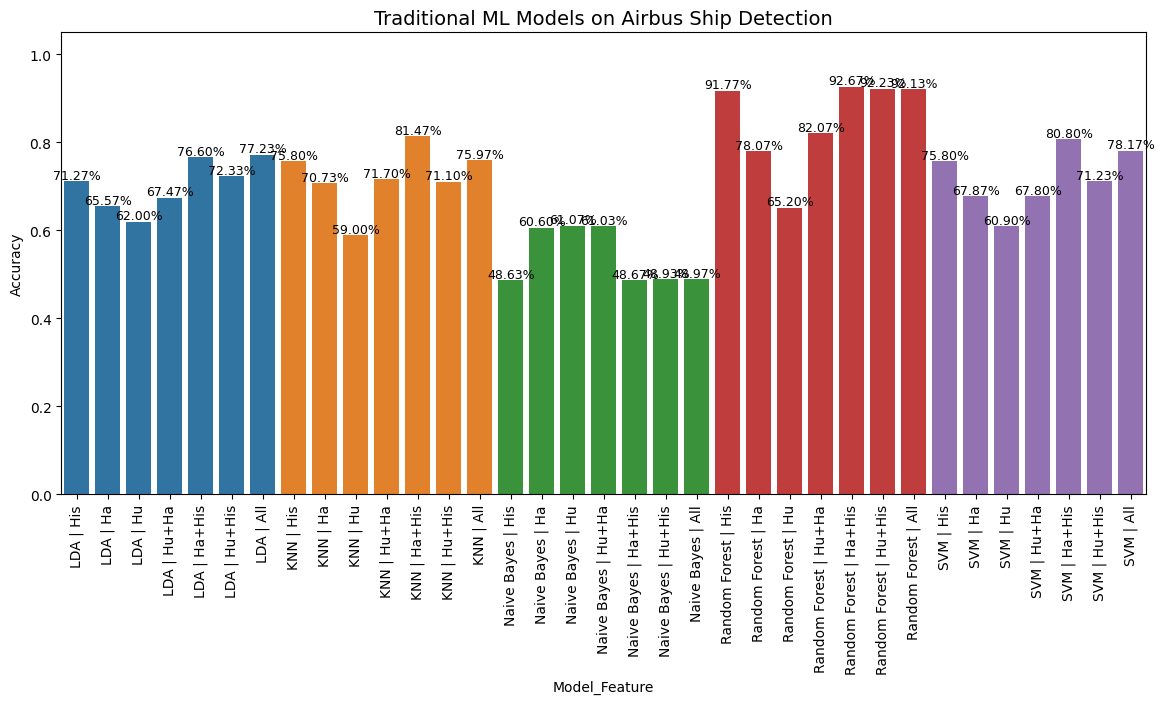

In [6]:
# ==============================
# STEP 8: VISUALIZE RESULTS
# ==============================
model_order = ["LDA", "KNN", "Naive Bayes", "Random Forest", "SVM"]
feature_order = ["His", "Ha", "Hu", "Hu+Ha", "Ha+His", "Hu+His", "All"]

data_list = []
print("\n✅ Final Accuracies:")
for model in model_order:
    for feat in feature_order:
        key = f"{model} | {feat}"
        if key in results:
            acc_percent = results[key]*100
            data_list.append({"Model_Feature": key, "Accuracy": results[key]})
            print(f"{key}: {acc_percent:.2f}%")

results_df = pd.DataFrame(data_list)
palette = sns.color_palette("tab10", len(model_order))
model_colors = {model: palette[i] for i, model in enumerate(model_order)}
bar_colors = [model_colors[res.split(" | ")[0]] for res in results_df["Model_Feature"]]

plt.figure(figsize=(14,6))
sns.barplot(x='Model_Feature', y='Accuracy', data=results_df, palette=bar_colors)
plt.xticks(rotation=90)
for i, row in enumerate(results_df.itertuples()):
    plt.text(i, row.Accuracy + 0.005, f"{row.Accuracy*100:.2f}%", ha='center', fontsize=9)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Traditional ML Models on Airbus Ship Detection", fontsize=14)
plt.show()

In [9]:
# ---------------------------
# Train final RandomForest on best feature set and save model+scaler
# ---------------------------
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# 1) Find best Random Forest entry in results dict
rf_entries = {k: v for k, v in results.items() if k.startswith("Random Forest")}
if not rf_entries:
    raise RuntimeError("No Random Forest entries found in 'results'. Ensure 'results' exists and contains accuracies.")

best_key = max(rf_entries, key=lambda k: rf_entries[k])
best_acc = rf_entries[best_key]
print(f"Best Random Forest key: '{best_key}'  (accuracy: {best_acc*100:.2f}%)")

feat_suffix = best_key.split(" | ")[1]
print("Selected feature set for final RF:", feat_suffix)

# 2) Helper to build feature matrices
def build_feature_matrix(suffix, hu, ha, his):
    if suffix == "His":
        return his
    elif suffix == "Ha":
        return ha
    elif suffix == "Hu":
        return hu
    elif suffix == "Hu+Ha":
        return np.hstack((hu, ha))
    elif suffix == "Ha+His":
        return np.hstack((ha, his))
    elif suffix == "Hu+His":
        return np.hstack((hu, his))
    elif suffix == "All":
        return np.hstack((hu, ha, his))
    else:
        raise ValueError(f"Unknown feature suffix: {suffix}")

# 3) Build train/test feature matrices (these arrays must already exist)
train_X = build_feature_matrix(feat_suffix, train_hu, train_ha, train_his)
test_X  = build_feature_matrix(feat_suffix, test_hu, test_ha, test_his)
print("Train X shape:", train_X.shape, "Test X shape:", test_X.shape)

# 4) Scale features (fit only on train)
scaler = MinMaxScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled  = scaler.transform(test_X)

# 5) Train final RandomForest
final_rf = RandomForestClassifier(
    n_estimators=140, max_depth=30, min_samples_leaf=1,
    max_features='sqrt', random_state=9, n_jobs=-1
)
print("Training final Random Forest on selected features...")
final_rf.fit(train_X_scaled, y_train)

# quick eval
preds = final_rf.predict(test_X_scaled)
acc = accuracy_score(y_test, preds)
print(f"Final RF test accuracy: {acc*100:.2f}%")
print(classification_report(y_test, preds))

# 6) Save model + scaler
os.makedirs("models", exist_ok=True)
model_path = "models/random_forest_ship_classifier.pkl"
scaler_path = "models/minmax_scaler.pkl"
joblib.dump(final_rf, model_path)
joblib.dump(scaler, scaler_path)
print(f"Saved RandomForest -> {model_path}")
print(f"Saved MinMaxScaler -> {scaler_path}")

# 7) Inference helper (use this to classify a numpy RGB image)
import cv2
def rf_predict_image_array(img_rgb, model, scaler, img_size=256):
    """
    img_rgb: HxWx3 RGB numpy array
    returns: (label, prob) where label is 0/1 and prob is model's ship probability
    """
    img_rs = cv2.resize(img_rgb, (img_size, img_size))
    hu = extract_hu_moments(img_rs)
    ha = extract_haralick_features(img_rs)
    his = extract_color_histogram(img_rs)
    # build features consistent with feat_suffix
    if feat_suffix == "All":
        feats = np.hstack((hu, ha, his)).reshape(1, -1)
    else:
        # use build_feature_matrix on 1-row arrays; ensure shapes align
        feats = build_feature_matrix(feat_suffix, hu.reshape(1,-1), ha.reshape(1,-1), his.reshape(1,-1))
        feats = feats.reshape(1, -1)
    feats = scaler.transform(feats)
    prob = model.predict_proba(feats)[0,1]
    label = int(model.predict(feats)[0])
    return label, float(prob)

print("Ready: use rf_predict_image_array(img_rgb, final_rf, scaler) to classify a new image.")


Best Random Forest key: 'Random Forest | Ha+His'  (accuracy: 92.67%)
Selected feature set for final RF: Ha+His
Train X shape: (12000, 518) Test X shape: (3000, 518)
Training final Random Forest on selected features...
Final RF test accuracy: 92.67%
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1200
           1       0.92      0.96      0.94      1800

    accuracy                           0.93      3000
   macro avg       0.93      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000

Saved RandomForest -> models/random_forest_ship_classifier.pkl
Saved MinMaxScaler -> models/minmax_scaler.pkl
Ready: use rf_predict_image_array(img_rgb, final_rf, scaler) to classify a new image.


In [11]:
# =========================================
# ✅ SAVE FINAL RANDOM FOREST MODEL + SCALER
# =========================================
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ Find the best Random Forest result
rf_entries = {k: v for k, v in results.items() if k.startswith("Random Forest")}
if not rf_entries:
    raise RuntimeError("No Random Forest entries found in results dictionary.")

best_key = max(rf_entries, key=lambda k: rf_entries[k])
best_acc = rf_entries[best_key]
feat_suffix = best_key.split(" | ")[1]
print(f"🏆 Best Random Forest: {best_key} (Accuracy = {best_acc*100:.2f}%)")

# 2️⃣ Helper to build feature matrices based on suffix
def build_feature_matrix(suffix, hu, ha, his):
    if suffix == "His": return his
    if suffix == "Ha": return ha
    if suffix == "Hu": return hu
    if suffix == "Hu+Ha": return np.hstack((hu, ha))
    if suffix == "Ha+His": return np.hstack((ha, his))
    if suffix == "Hu+His": return np.hstack((hu, his))
    if suffix == "All": return np.hstack((hu, ha, his))
    raise ValueError(f"Unknown feature suffix: {suffix}")

# 3️⃣ Build feature matrices
train_X = build_feature_matrix(feat_suffix, train_hu, train_ha, train_his)
test_X  = build_feature_matrix(feat_suffix, test_hu, test_ha, test_his)

print("Train shape:", train_X.shape, "| Test shape:", test_X.shape)

# 4️⃣ Scale features (fit on train only)
scaler = MinMaxScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled  = scaler.transform(test_X)

# 5️⃣ Train final Random Forest
final_rf = RandomForestClassifier(
    n_estimators=140, max_depth=30, min_samples_leaf=1,
    max_features='sqrt', random_state=9, n_jobs=-1
)
print("🚀 Training final Random Forest on best features...")
final_rf.fit(train_X_scaled, y_train)

# 6️⃣ Evaluate quickly
preds = final_rf.predict(test_X_scaled)
acc = accuracy_score(y_test, preds)
print(f"✅ Final Test Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, preds))

# 7️⃣ Save model + scaler
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "random_forest_ship_classifier.pkl")
scaler_path = os.path.join("models", "minmax_scaler.pkl")

joblib.dump(final_rf, model_path)
joblib.dump(scaler, scaler_path)

print("\n💾 Model and Scaler Saved Successfully!")
print(f"📁 Model file:   {os.path.abspath(model_path)}")
print(f"📁 Scaler file:  {os.path.abspath(scaler_path)}")


🏆 Best Random Forest: Random Forest | Ha+His (Accuracy = 92.67%)
Train shape: (12000, 518) | Test shape: (3000, 518)
🚀 Training final Random Forest on best features...
✅ Final Test Accuracy: 92.67%
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1200
           1       0.92      0.96      0.94      1800

    accuracy                           0.93      3000
   macro avg       0.93      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000


💾 Model and Scaler Saved Successfully!
📁 Model file:   c:\Users\shour\Desktop\AirBus\Airbus_Ship_Detection\models\models\random_forest_ship_classifier.pkl
📁 Scaler file:  c:\Users\shour\Desktop\AirBus\Airbus_Ship_Detection\models\models\minmax_scaler.pkl
